1. Imports & Setup

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add 'src' to the Python path
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from utils import load_data
from models import train_model, predict_pass_probabilities, evaluate_predictions

%matplotlib inline
print("Setup complete. SRC folder added to path.")

Setup complete. SRC folder added to path.


2. Load Data

In [2]:
# 1. Load the engineered features (the 22-row-per-pass dataset)
df_features = pd.read_csv('../data/processed/train_features.csv')

# 2. Load the original raw data (to get the true targets 'y')
_, y_full_original, _ = load_data()

print(f"Loaded Features Shape: {df_features.shape}")
print(f"Loaded Original Labels: {y_full_original.shape}")

Loading data from c:\Users\ANKRI\Desktop\Q1\ELEN0062-1\Project3\Football-pass-prediction\data\raw...
Loaded Features Shape: (191092, 16)
Loaded Original Labels: (8686, 1)


3. Create Train/ Validation Split

In [3]:
# Get unique pass IDs
unique_pass_ids = df_features['pass_id'].unique()
print(f"Total unique passes: {len(unique_pass_ids)}")

# Define split size (e.g., first 7000 passes for Train, rest for Validation)
split_index = 7000
train_ids = unique_pass_ids[:split_index]
val_ids = unique_pass_ids[split_index:]

# Create masks to filter the big DataFrame
train_mask = df_features['pass_id'].isin(train_ids)
val_mask = df_features['pass_id'].isin(val_ids)

# Split Features
# We drop columns that aren't features (IDs, targets)
cols_to_drop = ['pass_id', 'target', 'candidate_id', 'sender_id']
X_train = df_features[train_mask].drop(columns=cols_to_drop)
y_train_target = df_features[train_mask]['target']

X_val = df_features[val_mask].drop(columns=cols_to_drop)

# Prepare True Labels for Validation (for the metric calculation)
y_val_true = y_full_original.loc[val_ids]

print(f"Training on {len(train_ids)} passes.")
print(f"Validating on {len(val_ids)} passes.")

Total unique passes: 8686
Training on 7000 passes.
Validating on 1686 passes.


4. Train the Model

In [4]:
# Train the Random Forest
model = train_model(X_train, y_train_target)

print("Model training complete.")

Training Gradient Boosting with Calibration...
Model training complete.


5. Predict on Validation Set

In [5]:
print("Predicting on validation set...")

# Get normalized probabilities (DataFrame with pass_id and normalized_proba)
val_probas = predict_pass_probabilities(model, X_val, df_features[val_mask]['pass_id'])

print("Predictions generated.")
print(val_probas.head())

Predicting on validation set...
Predictions generated.
        pass_id  raw_proba  normalized_proba
154000     7000   0.070446          0.068603
154001     7000   0.076610          0.074606
154002     7000   0.000527          0.000514
154003     7000   0.011652          0.011347
154004     7000   0.022250          0.021668


6. Evaluate Model Performance

In [6]:
# Calculate Accuracy and Brier Score
acc, bs = evaluate_predictions(y_val_true, val_probas)

print("-" * 30)
print(f"Validation Accuracy:   {acc:.4f} ")
print(f"Validation Brier Score: {bs:.4f} ")
print("-" * 30)

# Store this accuracy! You will need it for the 'Estimated' field in the submission file.
estimated_accuracy = acc

------------------------------
Validation Accuracy:   0.3784 
Validation Brier Score: 0.7800 
------------------------------


7. Feature Importance Analysis

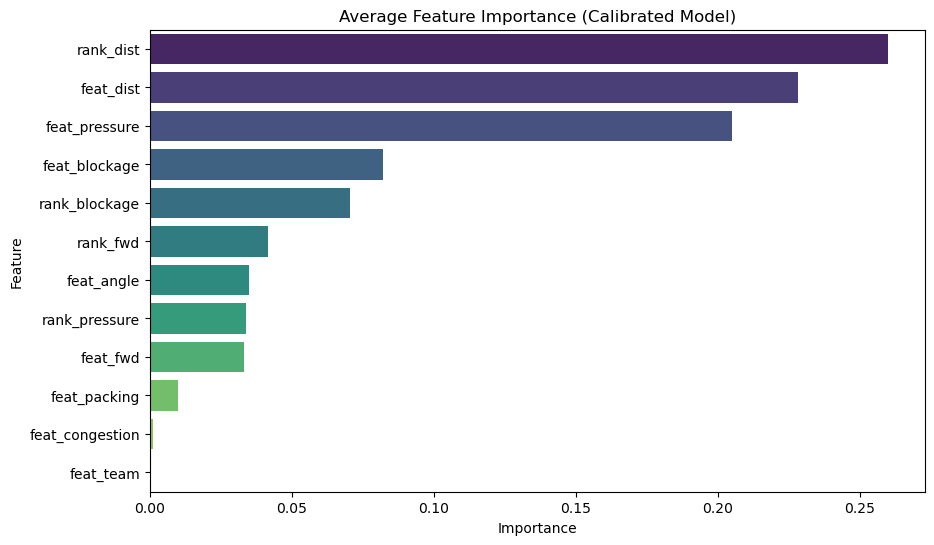

In [7]:
# Access the base estimators inside the CalibratedClassifierCV
# We average the importances across all the CV folds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Collect importances from each fold
all_importances = []
for calibrated_clf in model.calibrated_classifiers_:
    # Access the actual underlying model (e.g., HistGradientBoostingClassifier)
    base_model = calibrated_clf.estimator
    all_importances.append(base_model.feature_importances_)

# 2. Average them
avg_importances = np.mean(all_importances, axis=0)
feature_names = X_train.columns

# 3. Create DataFrame and Plot
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': avg_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title("Average Feature Importance (Calibrated Model)")
plt.show()

8. Retrain on Full Training Set

In [8]:
# --- ONLY RUN THIS WHEN READY TO SUBMIT ---
print("Retraining on FULL dataset for submission...")

# Use all features
X_full = df_features.drop(columns=cols_to_drop)
y_full = df_features['target']

final_model = train_model(X_full, y_full)
print("Final model trained.")

Retraining on FULL dataset for submission...
Training Gradient Boosting with Calibration...
Final model trained.
